In [1]:
import numpy as np
from tensorflow.keras.models import Sequential
from keras.layers import Dense, LSTM,Flatten

In [2]:
def prepare(time_seires, n):
    X,y = [],[]
    
    for i in range(len(time_seires)):
        # finding the end of patern 
        end_ix = i+n
        # cheak wheather if we are beyound the sequance 
        if end_ix > len(time_seires)-1:
            break
        
        #  gather the i/p & o/p of the pattern 
        seq_x, seq_y = time_seires[i:end_ix], time_seires[end_ix]
        X.append(seq_x)
        y.append(seq_y)
        
    return np.array(X) , np.array(y) 

In [3]:
time_series = [110,125,135,146,158,172,187,172,187,196,210]
n=3  # we will predict the o/p basis on the last 3 days data

X, y = prepare(time_series, n)
X

array([[110, 125, 135],
       [125, 135, 146],
       [135, 146, 158],
       [146, 158, 172],
       [158, 172, 187],
       [172, 187, 172],
       [187, 172, 187],
       [172, 187, 196]])

In [4]:
# before building a lstm you must known the shape of your input dara i.e. (X)
X.shape

(8, 3)

In [5]:
# now we reshape the X for the lstm 
#  [samples ,timesteps, featue]
#  the first dim -> no. of row || 2nd dim -> no.col || 3rd dim -> no. of feature in your data  
X  = X.reshape(X.shape[0], X.shape[1], 1) 
X.shape

(8, 3, 1)

In [6]:
# building the LSTM
model = Sequential()
model.add(LSTM(32, activation='relu', return_sequences=True, input_shape = (X.shape[0],X.shape[2])))
model.add(LSTM(64, activation='relu',return_sequences=True))
model.add(LSTM(32, activation='relu'))
model.add(Dense(1))
model.compile(optimizer = 'adam', loss='mse')

#  fit the model 
# verbose=0 → no output during training
# verbose=1 → progress bar
# verbose=2 → one line per epoch


model.fit(X, y, epochs=200, verbose=0)
model.summary()

C:\Users\shubham yadav\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 8, 32)          │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 8, 64)          │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,901 (487.90 KB)

 Trainable params: 41,633 (162.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 83,268 (325.27 KB)

In [ ]:
x_input = [187, 196, 220, 225]
output = []

for i in range(10):
    x = np.array(x_input[-3:]).reshape(1,3,1)  # we taking the last 3 value for prediction
    y = model.predict(x, verbose=0)[0][0] # predicting the next day value
    print(f"Day {i+1} : {y}") # printing value
    x_input.append(y) # appending in the inpu data 
    output.append(y)
    
# print("Next 10 days", output)

Day 1 : 221.00119018554688
Day 2 : 234.50271606445312
Day 3 : 238.46310424804688
Day 4 : 240.87063598632812
Day 5 : 249.98741149902344
Day 6 : 254.50404357910156
Day 7 : 259.35394287109375
Day 8 : 266.7386779785156
Day 9 : 272.0519714355469
Day 10 : 277.97998046875


In [ ]:
# our prediction 
np.array(output)

array([221.00119, 234.50272, 238.4631 , 240.87064, 249.98741, 254.50404,
       259.35394, 266.73868, 272.05197, 277.97998], dtype=float32)

Now we plot the prediction

In [32]:
import matplotlib.pylab as plt 

In [46]:
full_data = x_input + output
full_data = np.array(full_data , dtype=int)
# full_data = list(map(int,full_data))
# print(full_data)

days = np.arange(1,11)
days

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

ValueError: x and y must have same first dimension, but have shapes (8,) and (22,)

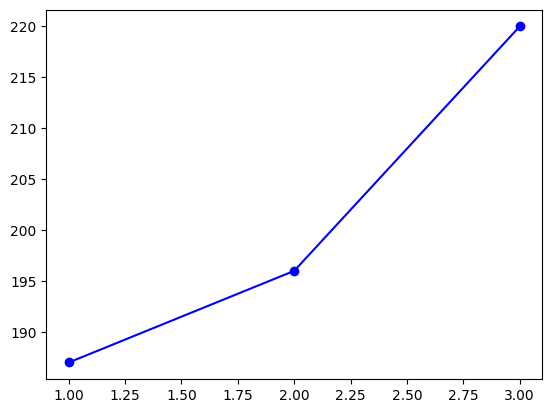

In [50]:
plt.plot(days[:3], full_data[:3], "bo-",  label='Original Data')
plt.plot(days[2:], full_data[2:], "ro", label='predicted Data')